# Variational Data Assimilation — Strong-Constraint 4DVar with vardax

The [ensemble-filtering tutorial](data_assimilation_etkf.ipynb) corrected a
somax state with [`filterax`](https://github.com/jejjohnson/filterax). This
one takes the **variational** route: [`vardax`](https://github.com/jejjohnson/vardax)
**strong-constraint 4DVar**, which finds the initial state $x_0$ whose
model trajectory best fits a whole *window* of observations, regularised
toward a background $x_b$:

$$
J(x_0) = \tfrac{1}{2}\,\|x_0 - x_b\|^2_{B^{-1}}
       + \tfrac{1}{2}\sum_{t=0}^{T} \|y_t - H_t\,M_t(x_0)\|^2_{R_t^{-1}}.
$$

**What you'll learn:**

1. The `somax.da.SomaxForwardModel` adapter that exposes a somax model as a
   vardax `ForwardModel`
2. How to build a structured background covariance $B$ with
   [`gaussx`](https://github.com/jejjohnson/gaussx)
3. How the 4DVar analysis pulls a poor background toward the truth

```{note}
This tutorial needs the optional `da` dependency group, which provides
`vardax` and `gaussx`:

    uv sync --group da
```

## The bridge: one adapter, two DA paradigms

`vardax`'s variational solvers consume a `pipekit_cycle.ForwardModel` — an
object with `dt` and `step(state, dt)` — and roll it out over the window
with `jax.lax.scan` on a **flat** state vector. `somax.da.SomaxForwardModel`
wraps a somax model to that contract (ravel → `model.step` → unravel),
exactly mirroring how `SomaxDynamics` adapted the same model for filterax's
*ensemble* filters. The forward model is shared; only the analysis paradigm
differs.

In [1]:
from __future__ import annotations

import gaussx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
from vardax import Batch1D, MaskedIdentity, StrongFourDVar

from somax.da import SomaxForwardModel, state_to_vector
from somax.models import L96State, Lorenz96

## 1. Truth, model, and the forward adapter

We use a 12-variable Lorenz '96 system at $F = 8$, spun onto its attractor.
`SomaxForwardModel` wraps the model with a fixed window `dt`; the `template`
state fixes the flat ↔ pytree layout.

In [2]:
K = 12
dt = 0.05
n_steps = 3  # assimilation-window length (T)
obs_var = 0.04  # observation-error variance

model = Lorenz96.create(F=8.0)
step = jax.jit(lambda s: model.step(s, dt))

truth = L96State(x=8.0 * jnp.ones(K).at[0].add(0.01))
for _ in range(200):
    truth = step(truth)
x0_true, _ = state_to_vector(truth)

forward = SomaxForwardModel(model=model, template=truth, dt=dt)
print("forward model dt:", forward.dt)

forward model dt: 0.05


## 2. The observation window

Strong 4DVar fits a *trajectory*: we roll the truth forward `n_steps` times
and observe every grid point at each time with Gaussian noise. vardax packs
the window into a `Batch1D` of shape `(batch, T+1, N)` with a validity mask.

In [3]:
traj = [x0_true]
state = truth
for _ in range(n_steps):
    state = step(state)
    vec, _ = state_to_vector(state)
    traj.append(vec)
traj = jnp.stack(traj)  # (T+1, K)

noise = jnp.sqrt(obs_var) * jax.random.normal(jax.random.PRNGKey(0), traj.shape)
batch = Batch1D(
    input=(traj + noise)[None],  # (1, T+1, K)
    mask=jnp.ones_like(traj)[None],
    target=traj[None],
)
print("observation window:", batch.input.shape)

observation window: (1, 4, 12)


## 3. Structured background covariance with gaussx

The background term $\|x_0 - x_b\|^2_{B^{-1}}$ needs a covariance $B$. Rather
than a plain diagonal, we build a **diagonal + low-rank** structure with
`gaussx.LowRankUpdate` — the kind of structured operator gaussx specialises
in — then materialise it as a dense PSD operator for vardax's solver. The
low-rank term injects spatial correlations the analysis can exploit.

In [4]:
psd = lx.positive_semidefinite_tag
u = jax.random.normal(jax.random.PRNGKey(2), (K, 2)) * 0.3
B_struct = gaussx.LowRankUpdate(
    lx.DiagonalLinearOperator(0.5 * jnp.ones(K)), u, jnp.ones(2), tags=psd
)
B = lx.MatrixLinearOperator(B_struct.as_matrix(), psd)
R = lx.MatrixLinearOperator(jnp.diag(obs_var * jnp.ones(K)), psd)
print(f"B condition number: {float(jnp.linalg.cond(B_struct.as_matrix())):.2f}")

B condition number: 3.69


## 4. Run strong-constraint 4DVar

The background is the truth corrupted by a sizeable perturbation — this is
what 4DVar has to correct. `StrongFourDVar` minimises $J(x_0)$ over the
initial state; gradients flow through the `SomaxForwardModel` rollout by
JAX autodiff.

In [5]:
background = x0_true + 0.3 * jax.random.normal(jax.random.PRNGKey(1), (K,))

strong = StrongFourDVar(
    forward=forward,
    obs_op=MaskedIdentity(),
    prior_mean=background,
    prior_cov_op=B,
    obs_cov_op=R,
)
analysis = strong(batch)[0]

bg_rmse = float(jnp.sqrt(jnp.mean((background - x0_true) ** 2)))
an_rmse = float(jnp.sqrt(jnp.mean((analysis - x0_true) ** 2)))
print(f"background RMSE vs truth: {bg_rmse:.4f}")
print(f"analysis   RMSE vs truth: {an_rmse:.4f}")
print(f"error reduction: {100 * (1 - an_rmse / bg_rmse):.0f}%")

background RMSE vs truth: 0.2460
analysis   RMSE vs truth: 0.1045
error reduction: 58%


## 5. Does it work?

The 4DVar analysis sits much closer to the truth than the background it
started from — the observation window has pulled $x_0$ back toward reality.

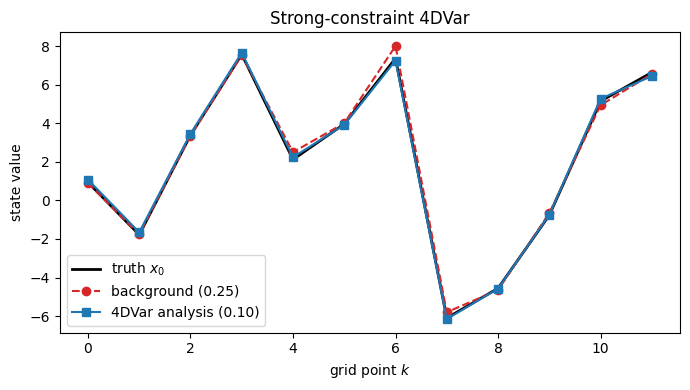

In [6]:
grid = jnp.arange(K)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, x0_true, "k-", lw=2, label="truth $x_0$")
ax.plot(grid, background, "o--", c="tab:red", label=f"background ({bg_rmse:.2f})")
ax.plot(grid, analysis, "s-", c="tab:blue", label=f"4DVar analysis ({an_rmse:.2f})")
ax.set(xlabel="grid point $k$", ylabel="state value", title="Strong-constraint 4DVar")
ax.legend()
fig.tight_layout()
plt.show()

## Summary

- `somax.da.SomaxForwardModel` exposes **any** somax model as a vardax
  `ForwardModel` — the same model that drove filterax's ensemble filters now
  drives variational 4DVar, no changes required.
- `gaussx` supplies structured background/observation covariances
  (`LowRankUpdate` here; `Kronecker`, `SVDLowRankUpdate`, … are available)
  as `lineax`-compatible operators.
- Strong-constraint 4DVar recovers the initial state from a windowed set of
  noisy observations, cutting the background error substantially.

```{note}
Strong 4DVar over a *fully chaotic* model is sensitive to the window length
and background error: a long rollout from a poor $x_0$ can diverge inside
the outer minimiser. This demo uses a short window; `vardax`'s
`IncrementalFourDVar` (Gauss-Newton inner loops) is the robust choice for
longer chaotic windows.
```